In [1]:
## Load libraries
import os
import pandas as pd

# Import shared helpers and TaxSolver components
from case_helpers import (
    tx, DataLoader, BracketInput,
    BudgetConstraint, IncomeConstraint, MarginalPressureConstraint, BracketConstraint,
    BudgetObjective, GurobiBackend,
    load_simple_simul_data, filter_low_income_households,
)

In [2]:
## Load data
file_path = os.path.join('data', 'simple_simul_1000.xlsx')
df_taxpayers = pd.read_excel(file_path)
df_taxpayers['tax'] = df_taxpayers['income_before_tax'] - df_taxpayers['outcome_3']

## Case 2: Complex Tax Rules (outcome_3)

#### Case 2: Recover

In [3]:
dl = DataLoader(path=df_taxpayers, income_before_tax="income_before_tax", income_after_tax="outcome_3")

tax_solver = tx.TaxSolver(
    dl.households,
    backend=GurobiBackend(),
)

# Define inflection points for general bracket structure
inflection_points = [0, 25_000, 50_000, 75_000, 100_000, 200_000]

# Add split variables for general income brackets (for everybody)
BracketInput.add_split_variables_to_solver(
    tx=tax_solver,
    target_var="income_before_tax",
    inflection_points=inflection_points,
    group_vars=["k_everybody"],
)

# Add split variables for single-specific brackets on household income
BracketInput.add_split_variables_to_solver(
    tx=tax_solver,
    target_var="household_income_before_tax",
    inflection_points=[30_000, 40_000],
    group_vars=["k_single"],
)

# Add split variables for couple-specific brackets on household income
BracketInput.add_split_variables_to_solver(
    tx=tax_solver,
    target_var="household_income_before_tax",
    inflection_points=[60_000, 75_000],
    group_vars=["k_couple"],
)

# Add split variables for ZZP-specific brackets on income
BracketInput.add_split_variables_to_solver(
    tx=tax_solver,
    target_var="income_before_tax",
    inflection_points=[0, 15_000],
    group_vars=["k_zzp"],
)

# 1. General progressive income tax brackets
income_tax = tx.BracketRule(
    name="income_before_tax_k_everybody",
    var_name="income_before_tax",
    k_group_var="k_everybody",
    ub=1,
    lb=0,
)

# 2. Single-specific brackets for healthcare deductible
single_bracket = tx.BracketRule(
    name="household_income_before_tax_k_single",
    var_name="household_income_before_tax",
    k_group_var="k_single",
    ub=0.8,
    lb=-0.5,
)

# 3. Couple-specific brackets for healthcare deductible
couple_bracket = tx.BracketRule(
    name="household_income_before_tax_k_couple",
    var_name="household_income_before_tax",
    k_group_var="k_couple",
    ub=0.8,
    lb=-0.5,
)

# 4. ZZP-specific brackets for tax credit
zzp_bracket = tx.BracketRule(
    name="income_before_tax_k_zzp",
    var_name="income_before_tax",
    k_group_var="k_zzp",
    ub=0.8,
    lb=-0.5,
)

# 5. Benefits
children_benefit = tx.BenefitRule(
    name="benefit_children",
    var_name="i_children",
)

couple_benefit = tx.BenefitRule(
    name="benefit_couple",
    var_name="k_couple",
)

single_benefit = tx.BenefitRule(
    name="benefit_single",
    var_name="k_single",
)

tax_solver.add_rules([
    income_tax, 
    single_bracket, 
    couple_bracket, 
    zzp_bracket,
    children_benefit,
    couple_benefit,
    single_benefit
])

income_constraint = IncomeConstraint(0.00000001, dl.households.values()) ## Tight constraints for recovery

# No budget bound: the loose cap below is non-binding and only keeps the
# spend variable that defines the revenue-loss objective
budget_constraint = BudgetConstraint(
    "All_households", dl.households.values(), 1_000_000_000
)

# Marginal pressure constraint (max_marginal_pressure=1)
marginal_pressure_constraint = MarginalPressureConstraint(1.0)

tax_solver.add_constraints([
    income_constraint, 
    budget_constraint, 
    marginal_pressure_constraint
])

objective = BudgetObjective(budget_constraint)
tax_solver.add_objective(objective)

tax_solver.solve()

pd.set_option('display.float_format', '{:.6f}'.format)
r_and_r = tax_solver.rules_and_rates_table()
r_and_r_recover_mg = r_and_r.copy()
r_and_r

Directly loading from pd.DataFrame...
Setting 'weight' to 1 as default.
Mirror household were missing for 669 households: set to own id
Set parameter Username


Academic license - for non-commercial use only - expires 2027-07-08


Current tax balance All_households: -18038295
New Maximum: 981961705
Going to solve!
Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (mac64[arm] - Darwin 24.6.0 24G720)


CPU model: Apple M4 Max


Thread count: 16 physical cores, 16 logical processors, using up to 16 threads


...

Solution count 1: 481.049 


Optimal solution found (tolerance 1.00e-04)


Best objective 4.810489190444e+02, best bound 4.810489190444e+02, gap 0.0000%


Found at least one feasible solution!


,rule_name,rule_type,var_name,rate,b,weight
0,income_before_tax_k_everybody__income_before_t...,FlatTaxRule,income_before_tax_k_everybody_0_25000,0.100005,1,1
1,income_before_tax_k_everybody__income_before_t...,FlatTaxRule,income_before_tax_k_everybody_25000_50000,0.199992,1,1
2,income_before_tax_k_everybody__income_before_t...,FlatTaxRule,income_before_tax_k_everybody_50000_75000,0.300004,1,1
3,income_before_tax_k_everybody__income_before_t...,FlatTaxRule,income_before_tax_k_everybody_75000_100000,0.399995,1,1
4,income_before_tax_k_everybody__income_before_t...,FlatTaxRule,income_before_tax_k_everybody_100000_200000,0.500000,1,1
5,household_income_before_tax_k_single__househol...,FlatTaxRule,household_income_before_tax_k_single_30000_40000,0.150012,1,1
6,household_income_before_tax_k_couple__househol...,FlatTaxRule,household_income_before_tax_k_couple_60000_75000,0.075024,1,1
7,income_before_tax_k_zzp__income_before_tax_k_z...,FlatTaxRule,income_before_tax_k_zzp_0_15000,-0.099997,1,1
8,benefit_children,BenefitRule,i_children,799.974859,1,1
9,benefit_couple,BenefitRule,k_couple,1125.811295,1,1


#### Case 2: Reform

In [4]:
tax_solver = tx.TaxSolver(
    dl.households,
    backend=GurobiBackend(),
)

# Define inflection points for general bracket structure
inflection_points = [0, 25_000, 50_000, 75_000, 100_000, 200_000]

BracketInput.add_split_variables_to_solver(
    tx=tax_solver,
    target_var="income_before_tax",
    inflection_points=inflection_points,
    group_vars=["k_everybody"],
)

income_tax = tx.BracketRule(
    name="income_before_tax_k_everybody",
    var_name="income_before_tax",
    k_group_var="k_everybody",
    ub=1,
    lb=0,
)

children_benefit = tx.BenefitRule(
    name="benefit_children",
    var_name="i_children",
)

universal_benefit = tx.BenefitRule(
    name="benefit_everybody",
    var_name="k_everybody",
)

tax_solver.add_rules([income_tax, children_benefit, universal_benefit])

income_constraint = IncomeConstraint(0.10, dl.households.values()) # All households: 10% max income loss

# Household group <85k must gain at least 5% increase in net income
low_income_households = [
    hh for hh in dl.households.values() 
    if hh.members[0]["household_income_before_tax"] < 85_000
]
income_constraint_low_income = IncomeConstraint(-0.05, low_income_households)

# No budget bound: the loose cap below is non-binding and only keeps the
# spend variable that defines the revenue-loss objective
budget_constraint = BudgetConstraint(
    "All_households", dl.households.values(), 1_000_000_000
)

# Marginal pressure constraint (max_marginal_pressure=0.6)
marginal_pressure_constraint = MarginalPressureConstraint(0.6)

tax_solver.add_constraints([
    income_constraint, 
    income_constraint_low_income,
    budget_constraint, 
    marginal_pressure_constraint
])

bracket_constraint = BracketConstraint(
    rule_family="income_before_tax_k_everybody",
    max_brackets=None,
    ascending=True,
    start_from_first_inflection=False,
    last_bracket_zero=False,
)
bracket_constraint.brackets = income_tax.flat_rules
tax_solver.add_constraints([bracket_constraint])

objective = BudgetObjective(budget_constraint)
tax_solver.add_objective(objective)

tax_solver.solve()

pd.set_option('display.float_format', '{:.6f}'.format)
r_and_r = tax_solver.rules_and_rates_table()
r_and_r_reform_mg = r_and_r.copy()  # consumed by the figure cell
r_and_r

Current tax balance All_households: -18038295
New Maximum: 981961705
Going to solve!
Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (mac64[arm] - Darwin 24.6.0 24G720)


CPU model: Apple M4 Max


Thread count: 16 physical cores, 16 logical processors, using up to 16 threads


Optimize a model with 3893 rows, 1017 columns and 6705 nonzeros


Model fingerprint: 0x75aff378


...

Solution count 1: 1.96193e+06 


Optimal solution found (tolerance 1.00e-04)


Best objective 1.961929144658e+06, best bound 1.961929144658e+06, gap 0.0000%


Found at least one feasible solution!


,rule_name,rule_type,var_name,rate,b,weight
0,income_before_tax_k_everybody__income_before_t...,FlatTaxRule,income_before_tax_k_everybody_0_25000,0.051927,1,1
1,income_before_tax_k_everybody__income_before_t...,FlatTaxRule,income_before_tax_k_everybody_25000_50000,0.206821,1,1
2,income_before_tax_k_everybody__income_before_t...,FlatTaxRule,income_before_tax_k_everybody_50000_75000,0.206821,1,1
3,income_before_tax_k_everybody__income_before_t...,FlatTaxRule,income_before_tax_k_everybody_75000_100000,0.600000,1,1
4,income_before_tax_k_everybody__income_before_t...,FlatTaxRule,income_before_tax_k_everybody_100000_200000,0.600000,1,1
5,benefit_children,BenefitRule,i_children,713.250000,1,1
6,benefit_everybody,BenefitRule,k_everybody,3479.745578,1,1


## Visualization: Tax System Plots

In [5]:
# Helper functions and configuration for plots
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Import shared plotting helpers
from case_helpers import euro_format, euro_format_full, wrangle_intervals, build_tax_line

# Configuration - aligned with other case plots
Y_TITLE = "Taxes paid (€)"
X_TITLE = "Income before tax (€)"
TICK_FONT_SIZE = 14

# Use RdYlBu colormap colors (blue for current, red for reform)
cmap = plt.cm.RdYlBu
COLOR_CURRENT = '#0072B2'  # Okabe-Ito blue: current system
COLOR_REFORM = '#D55E00'   # Okabe-Ito vermillion: TaxSolver reform
COLOR_ZZP = '#009E73'      # Okabe-Ito bluish green: self-employed
COLOR_FISCAL_PARTNERS = '#009E73'  # Okabe-Ito bluish green: fiscal partners

# Load taxpayer data (use first 100 for simple visualization)
file_path_plot = os.path.join('data', 'simple_simul_1000.xlsx')
df_taxpayers_plot = pd.read_excel(file_path_plot)
df_taxpayers_plot = df_taxpayers_plot.iloc[0:100, :].copy()
df_taxpayers_plot["tax_3"] = df_taxpayers_plot["income_before_tax"] - df_taxpayers_plot["outcome_3"]

In [6]:
# Everything below comes from this notebook's own solves
from case_helpers import rates_to_intervals, benefit_value, pad_intervals

# Labour income brackets (recovery solve)
df_intervals_income = rates_to_intervals(r_and_r_recover_mg, rule_family="income_before_tax_k_everybody")
df_intervals_income = wrangle_intervals(df_intervals_income, df_taxpayers_plot)
x_income, y_income, current_y_income = build_tax_line(df_intervals_income, start_y=0)

# Self-employed: labour brackets plus the recovered ZZP credit on its bracket
zzp_adj = rates_to_intervals(r_and_r_recover_mg, rule_family="income_before_tax_k_zzp")
zzp_cut = float(zzp_adj["bracket_end"].iloc[0])
zzp_rate_adj = float(zzp_adj["rate"].iloc[0])
first = df_intervals_income.iloc[0]
df_intervals_zzp = pd.concat([
    pd.DataFrame([
        {"bracket_start": 0.0, "bracket_end": zzp_cut, "rate": first["rate"] + zzp_rate_adj},
        {"bracket_start": zzp_cut, "bracket_end": first["bracket_end"], "rate": first["rate"]},
    ]),
    df_intervals_income.iloc[1:][["bracket_start", "bracket_end", "rate"]],
], ignore_index=True)
x_zzp, y_zzp, _ = build_tax_line(df_intervals_zzp, start_y=0)

# Household benefit tapers (recovery solve), padded with zero-rate segments
BENEFIT_SINGLES = benefit_value(r_and_r_recover_mg, "benefit_single")
df_intervals_singles = pad_intervals(
    rates_to_intervals(r_and_r_recover_mg, rule_family="household_income_before_tax_k_single"))
df_intervals_singles = wrangle_intervals(df_intervals_singles, df_taxpayers_plot)
x_singles, y_singles, current_y_singles = build_tax_line(df_intervals_singles, start_y=-BENEFIT_SINGLES)

BENEFIT_COUPLES = benefit_value(r_and_r_recover_mg, "benefit_couple")
df_intervals_couples = pad_intervals(
    rates_to_intervals(r_and_r_recover_mg, rule_family="household_income_before_tax_k_couple"))
df_intervals_couples = wrangle_intervals(df_intervals_couples, df_taxpayers_plot)
x_couples, y_couples, current_y_couples = build_tax_line(df_intervals_couples, start_y=-BENEFIT_COUPLES)

# Reform (this notebook's reform solve)
BENEFIT_REFORM = benefit_value(r_and_r_reform_mg, "benefit_everybody")
CHILD_REFORM = benefit_value(r_and_r_reform_mg, "benefit_children")
df_intervals_reform = rates_to_intervals(r_and_r_reform_mg, rule_family="income_before_tax_k_everybody")
df_intervals_reform = wrangle_intervals(df_intervals_reform, df_taxpayers_plot)
x_reform, y_reform, current_y_reform = build_tax_line(df_intervals_reform, start_y=-BENEFIT_REFORM)


Saved ./output/figs/case_2_reform.png


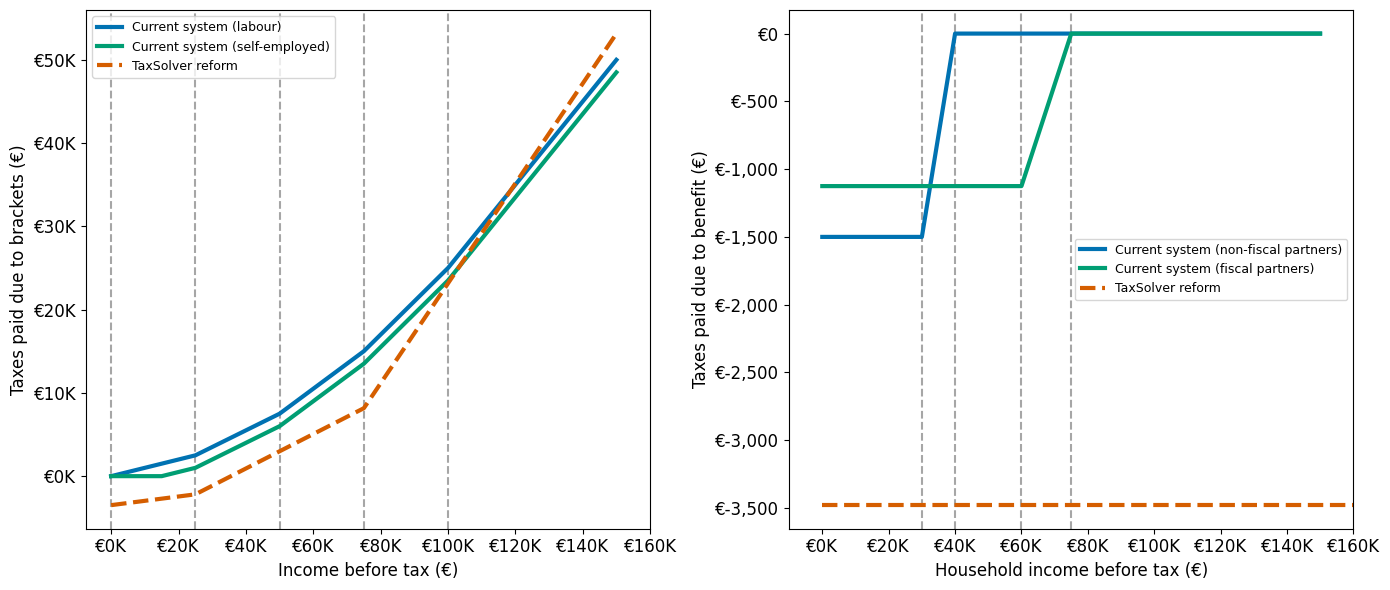

In [7]:
fig2, (bx1, bx2) = plt.subplots(1, 2, figsize=(14, 6))

for income in [0, 25_000, 50_000, 75_000, 100_000]:
    bx1.axvline(x=income, color="gray", linestyle="--", linewidth=1.5, alpha=0.7)
bx1.plot(x_income, y_income, label="Current system (labour)", color=COLOR_CURRENT, linestyle="-", linewidth=3)
bx1.plot(x_zzp, y_zzp, label="Current system (self-employed)", color=COLOR_ZZP, linestyle="-", linewidth=3)
bx1.plot(x_reform, y_reform, label="TaxSolver reform", color=COLOR_REFORM, linestyle="--", linewidth=3)
bx1.set_xlabel(X_TITLE, fontsize=12)
bx1.set_ylabel("Taxes paid due to brackets (\u20ac)", fontsize=12)
bx1.xaxis.set_major_formatter(FuncFormatter(euro_format))
bx1.yaxis.set_major_formatter(FuncFormatter(euro_format))
bx1.tick_params(axis='both', labelsize=12)
bx1.set_xlim(right=160_000)
bx1.legend(fontsize=9, loc='upper left')

for income in [30_000, 40_000, 60_000, 75_000]:
    bx2.axvline(x=income, color="gray", linestyle="--", linewidth=1.5, alpha=0.7)
bx2.plot(x_singles, y_singles, label="Current system (non-fiscal partners)", color=COLOR_CURRENT, linestyle="-", linewidth=3)
bx2.plot(x_couples, y_couples, label="Current system (fiscal partners)", color=COLOR_FISCAL_PARTNERS, linestyle="-", linewidth=3)
bx2.plot([0, 200_000], [-BENEFIT_REFORM, -BENEFIT_REFORM], label="TaxSolver reform",
         color=COLOR_REFORM, linestyle="--", linewidth=3)
bx2.set_xlabel("Household income before tax (\u20ac)", fontsize=12)
bx2.set_ylabel("Taxes paid due to benefit (\u20ac)", fontsize=12)
bx2.xaxis.set_major_formatter(FuncFormatter(euro_format))
bx2.yaxis.set_major_formatter(FuncFormatter(euro_format_full))
bx2.tick_params(axis='both', labelsize=12)
bx2.set_xlim(right=160_000)
bx2.legend(fontsize=9, loc='center right')

fig2.tight_layout()
fig2.savefig("./output/figs/case_2_reform.png", dpi=300, bbox_inches='tight')
print("Saved ./output/figs/case_2_reform.png")
plt.show()